### Bibliotecas

In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from google.cloud import bigquery
import io
from bs4 import BeautifulSoup
import urllib3
import uuid
import json
import joblib
from google import genai
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tempfile, os
from dotenv import load_dotenv

In [2]:
# Carregando o arquivo .env para carregar as variáveis na memória do sistema
load_dotenv()

# Chaves do código:
API_KEY_GEMINI = os.getenv("GEMINI_API_KEY")
PROJECT_ID = os.getenv("PROJECT_ID")
VC_API_KEY = os.getenv("VC_API_KEY")

# Dica de Sênior: Verifique se carregou
if not API_KEY_GEMINI:
    print("❌ Erro: Chave não encontrada! Verifique o arquivo .env")
else:
    print("🚀 Chaves carregadas com sucesso!")

🚀 Chaves carregadas com sucesso!


## 1. Dicionário de Pontos Estratégicos (Python)

In [3]:
DATASET_ID = "logisticsdata"
TABLE_ID_CLIMA = f"{PROJECT_ID}.{DATASET_ID}.fato_clima"
# --------------------------------

# Iniciar Cliente BigQuery
client = bigquery.Client(project=PROJECT_ID)
print(f"✅ BigQuery client iniciado. Project: {PROJECT_ID}")

F:\anaconda\envs\gemini_env\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✅ BigQuery client iniciado. Project: agrologisticsdata


In [4]:
# Pontos estratégicos definidos anteriormente
pontos_monitoramento = [
    {"loc_id": "PORTO_SANTOS_CANAL", "nome": "Canal de Acesso / Porto", "lat": -23.9608, "lon": -46.3339},
    {"loc_id": "SERRA_ANCHIETA_IMIGRANTES", "nome": "Sistema Anchieta-Imigrantes", "lat": -23.8919, "lon": -46.4961},
    {"loc_id": "AREA_FUNDEIO_SANTOS", "nome": "Área de Fundeio", "lat": -24.0150, "lon": -46.3000}
]

## 2. O Script de Extração "Sênior"

In [5]:
def backfill_clima_portos():
    global client
    job_config = bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")
    
    lista_dfs = []

    print(f"🛰️ Iniciando coleta para {len(pontos_monitoramento)} pontos estratégicos...")

    for ponto in pontos_monitoramento:
        # Usamos LAT,LON em vez do nome da cidade para precisão total no porto
        lat, lon = ponto['lat'], ponto['lon']
        loc_id = ponto['loc_id']
        
        url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{lat},{lon}/last15days?unitGroup=metric&include=days&key={VC_API_KEY}&contentType=csv"
        
        try:
            df_hist = pd.read_csv(url)
            
            # Criando o DataFrame específico para este ponto
            df_ponto = pd.DataFrame({
                'loc_id': loc_id,  # Agora ele usa o ID correto do dicionário
                'timestamp_leitura': pd.to_datetime(df_hist['datetime']),
                'precipitacao_mm': df_hist['precip'].fillna(0),
                'velocidade_vento': df_hist['windspeed'],
                'umidade': df_hist['humidity'],
                'alerta_critico': (df_hist['precip'] > 5) | (df_hist['windspeed'] > 15)
            })
            
            lista_dfs.append(df_ponto)
            print(f"✅ Dados coletados: {ponto['nome']} ({len(df_ponto)} registros)")

        except Exception as e:
            print(f"❌ Erro ao coletar ponto {loc_id}: {e}")

    # Consolida todos os pontos em um único envio para o BigQuery (mais eficiente)
    if lista_dfs:
        df_final = pd.concat(lista_dfs, ignore_index=True)
        job = client.load_table_from_dataframe(df_final, TABLE_ID_CLIMA, job_config=job_config)
        job.result()
        print(f"\n🚀 Sucesso Total! {len(df_final)} linhas enviadas para o BigQuery.")
    else:
        print("⚠️ Nenhum dado foi coletado.")

# Rodar a carga
backfill_clima_portos()

🛰️ Iniciando coleta para 3 pontos estratégicos...
✅ Dados coletados: Canal de Acesso / Porto (16 registros)
✅ Dados coletados: Sistema Anchieta-Imigrantes (16 registros)
✅ Dados coletados: Área de Fundeio (16 registros)

🚀 Sucesso Total! 48 linhas enviadas para o BigQuery.


## WebScraping porto de santos

In [6]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def extrair_lineup_santos():
    url = "https://www.portodesantos.com.br/informacoes-operacionais/operacao-portuaria/navegacao-e-movimentacao-de-navios/navios-esperados/"
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    print("Acessando o Line-up oficial do Porto de Santos...")
    response = requests.get(url, headers=headers, verify=False)
    
    if response.status_code != 200:
        print(f"Erro ao acessar site: {response.status_code}")
        return None

    soup = BeautifulSoup(response.text, 'html.parser')
    tabelas = soup.find_all('table')
    
    if not tabelas:
        print("Não foi possível encontrar a tabela de navios.")
        return None

    try:
        # Transformamos a string da tabela em um "arquivo de texto virtual" usando io.StringIO
        conteudo_html = io.StringIO(str(tabelas[0]))
        
        # Agora o pandas lê corretamente
        df_lista = pd.read_html(conteudo_html)[0]
        
        print(f"Tabela capturada com sucesso! ({len(df_lista)} registros)")
        return df_lista
    except Exception as e:
        print(f"Erro ao processar tabela: {e}")
        return None

# Executar
df_navios = extrair_lineup_santos()

if df_navios is not None:
    display(df_navios.head())

Acessando o Line-up oficial do Porto de Santos...
Tabela capturada com sucesso! (31 registros)


LIQUIDO A GRANEL                                        \
                Navio Ship Bandeira Flag Com/Len Cal/Draft   Nav   
0           WHITE CONDOR I      CAMAROES             183 9  Long   
1              BUNGO CROWN  DINAMARQUESA             185 9  Long   
2           AMAZON VICTORY         GREGA          228 11.2  Cabo   
3            FLUMAR BRASIL    BRASILEIRA            183 11  Cabo   
4  CASTILLO DE TEBRA (REB)    BRASILEIRA             120 6  Cabo   

                                       \
    Cheg/Arrival d/m/y Carimbo Notice   
0  03/03/2026 09:32:00         0976-8   
1  09/03/2026 08:40:00         1073-1   
2  11/03/2026 08:00:00         1098-7   
3  11/03/2026 08:45:00         1099-5   
4  12/03/2026 07:00:00         1115--   

                                                                 \
                                   Agência Office Operaç Operat   
0  NORTH STAR SUDESTE SERVICOS MARITIMOS LTDA-EPP          DESC   
1  NORTH STAR SUDESTE SERVICOS MARITIMOS LTDA-EPP          DESC   
2         CONE SUL AGENCIA DE NAVEGAÇÃO S/C LTDA.           EMB   
3         CONE SUL AGENCIA DE NAVEGAÇÃO S/C LTDA.           EMB   
4                 ORION OPERACOES PORTUARIAS LTDA      EMB DESC   

                                                                               \
            Mercadoria Goods Peso Weight Viagem Voyage        DUV  P Terminal   
0                OLEO DIESEL       26100   1082-4 2026   86182026  B     ILHA   
1                OLEO DIESEL        8742   1123-2 2026  105642026  B     ILHA   
2           OLEO COMBUSTIVEL       70000   1182-9 2026  111822026  B   ALAMOA   
3                OLEO DIESEL       40000   1054-- 2026   98902026  B   ALAMOA   
4  ETHANOL PRODUTOS QUIMICOS   8482 5400   1091-3 2026  101982026  B     ILHA   

           Unnamed: 15_level_0  
       IMO Unnamed: 15_level_1  
0  9255244                 NaN  
1  9925875                 NaN  
2  9660358                 NaN  
3  9416836                 NaN  
4  9753636                 NaN

## Data Wrangling (Limpeza e Padronização)

In [7]:
def limpar_lineup(df):
    df_clean = df.copy()
    
    # 1. Se for MultiIndex, "achata" as colunas primeiro
    if isinstance(df_clean.columns, pd.MultiIndex):
        df_clean.columns = [' '.join(col).strip() for col in df_clean.columns.values]
    
    # 2. Mapeamento Inteligente (Busca Parcial)
    # Definimos o que procuramos e como queremos que se chame
    mapeamento_alvo = {
        'Navio Ship': 'nome_navio',
        'Cheg/Arrival d/m/y': 'data_chegada_prevista',
        'Mercadoria Goods': 'commodity',
        'Peso Weight': 'quantidade_estimada',
        'Terminal': 'terminal',
        'IMO': 'ship_id'
    }
    
    # Criamos um novo dicionário de renomeação baseado no que REALMENTE existe no DF
    real_rename = {}
    for col_no_dataframe in df_clean.columns:
        for termo_procurado, nome_final in mapeamento_alvo.items():
            if termo_procurado in col_no_dataframe: # Aqui a mágica acontece
                real_rename[col_no_dataframe] = nome_final
    
    df_clean = df_clean.rename(columns=real_rename)
    
    # --- VALIDAÇÃO ---
    if 'data_chegada_prevista' not in df_clean.columns:
        raise KeyError(f"Não encontrei a coluna de data! Colunas detectadas: {df_clean.columns.tolist()}")

    # 3. Tratamento de Dados
    # Converter data
    df_clean['data_chegada_prevista'] = pd.to_datetime(
        df_clean['data_chegada_prevista'], dayfirst=True, errors='coerce'
    )
    
    # Converter peso
    if 'quantidade_estimada' in df_clean.columns:
        df_clean['quantidade_estimada'] = df_clean['quantidade_estimada'].astype(str)\
            .str.replace('.', '', regex=False)\
            .str.replace(',', '.', regex=False)\
            .replace('nan', '0')
        df_clean['quantidade_estimada'] = pd.to_numeric(df_clean['quantidade_estimada'], errors='coerce').fillna(0)

    # 4. Criar colunas obrigatórias
    df_clean['status_atual'] = 'Esperado'
    df_clean['data_atracacao_prevista'] = df_clean['data_chegada_prevista']
    df_clean['lineup_id'] = [str(uuid.uuid4()) for _ in range(len(df_clean))]
    
    # 5. Filtrar apenas colunas finais que existem
    colunas_finais = [
        'lineup_id', 'ship_id', 'data_chegada_prevista', 
        'data_atracacao_prevista', 'status_atual', 
        'terminal', 'commodity', 'quantidade_estimada'
    ]
    
    # Filtrar colunas que realmente existem para evitar erro de índice
    colunas_disponiveis = [c for c in colunas_finais if c in df_clean.columns]
    
    # Dropna apenas se o ship_id (IMO) existir
    if 'ship_id' in df_clean.columns:
        return df_clean[colunas_disponiveis].dropna(subset=['ship_id'])
    else:
        return df_clean[colunas_disponiveis]

# Executar a limpeza
df_lineup_final = limpar_lineup(df_navios)

print(f"Tabela limpa! {len(df_lineup_final)} navios processados.")
display(df_lineup_final.head())

Tabela limpa! 31 navios processados.


,lineup_id,ship_id,data_chegada_prevista,data_atracacao_prevista,status_atual,terminal,commodity,quantidade_estimada
0,513c2fac-c14a-40b7-b609-3f4244916581,9255244,2026-03-03 09:32:00,2026-03-03 09:32:00,Esperado,ILHA,OLEO DIESEL,26100.0
1,5c857d18-5f9f-4d67-89be-4aa92a0e49dd,9925875,2026-03-09 08:40:00,2026-03-09 08:40:00,Esperado,ILHA,OLEO DIESEL,8742.0
2,82584d76-3051-4cda-8b3a-9efbcb2fb6f8,9660358,2026-03-11 08:00:00,2026-03-11 08:00:00,Esperado,ALAMOA,OLEO COMBUSTIVEL,70000.0
3,39280ec0-a537-4417-90f7-b17d3624364c,9416836,2026-03-11 08:45:00,2026-03-11 08:45:00,Esperado,ALAMOA,OLEO DIESEL,40000.0
4,ff2436c1-d980-4ecf-97f8-e74348f620a7,9753636,2026-03-12 07:00:00,2026-03-12 07:00:00,Esperado,ILHA,ETHANOL PRODUTOS QUIMICOS,0.0


## Subindo o Line-up para o BigQuery

In [8]:
TABLE_ID_LINEUP = f"{PROJECT_ID}.{DATASET_ID}.fato_lineup"

try:
    df_lineup_final = df_lineup_final.copy()

    # Corrigir tipos para bater com o schema do BigQuery
    df_lineup_final['ship_id'] = df_lineup_final['ship_id'].astype(str)
    df_lineup_final['data_chegada_prevista'] = pd.to_datetime(df_lineup_final['data_chegada_prevista']).dt.strftime('%Y-%m-%d')  # DATE
    df_lineup_final['data_atracacao_prevista'] = pd.to_datetime(df_lineup_final['data_atracacao_prevista']).dt.strftime('%Y-%m-%d %H:%M:%S')  # TIMESTAMP
    df_lineup_final['inserido_em'] = datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')  # coluna obrigatória


    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_APPEND",
        source_format=bigquery.SourceFormat.NEWLINE_DELIMITED_JSON,
    )

    print(f"Subindo {len(df_lineup_final)} navios para o BigQuery...")
    json_data = df_lineup_final.to_json(orient='records', lines=True)

    job = client.load_table_from_file(
        io.StringIO(json_data),
        TABLE_ID_LINEUP,
        job_config=job_config
    )
    job.result()
    print(f"✅ Sucesso! O Line-up do Porto de Santos foi atualizado no BigQuery.")

except Exception as e:
    print(f"❌ Erro ao subir para o BigQuery: {e}")

Subindo 31 navios para o BigQuery...
✅ Sucesso! O Line-up do Porto de Santos foi atualizado no BigQuery.


## O Motor de PLN & Sentimento de Risco

In [9]:
# No novo SDK, criamos um cliente que gerencia a conexão
gn_client = genai.Client(api_key=API_KEY_GEMINI)

# Agora o modelo não é "instanciado" como antes. 
# Você define o ID do modelo que quer usar para as chamadas.
model_name = 'gemini-flash-latest' 

In [10]:
TABLE_ID_NLP = f"{PROJECT_ID}.{DATASET_ID}.fato_contingencias_nlp"

def salvar_no_bigquery_free_tier(dados_ia, texto_original):
    global client  # ✅ Usa o client global, sem recriar
    print("📦 [1] Entrando na função...")

    registro = {
        "cont_id": str(uuid.uuid4()),
        "loc_id": "SANTOS_GERAL",
        "timestamp_leitura": pd.Timestamp.now(tz="UTC").isoformat(),
        "texto_original": texto_original,
        "entidade_evento": dados_ia.get("evento", "N/A"),
        "score_risco": 0.8,
        "json_extraido": json.dumps(dados_ia, ensure_ascii=False)
    }
    print(f"✅ [2] Registro montado: {registro}")

    with tempfile.NamedTemporaryFile(mode="w", suffix=".jsonl", delete=False, encoding="utf-8") as f:
        f.write(json.dumps(registro, ensure_ascii=False) + "\n")
        tmp_path = f.name
    print(f"✅ [3] Arquivo temporário: {tmp_path}")

    job_config = bigquery.LoadJobConfig(
        source_format=bigquery.SourceFormat.NEWLINE_DELIMITED_JSON,
        write_disposition="WRITE_APPEND",
        autodetect=False,
    )

    try:
        print(f"⏳ [4] Enviando para: {TABLE_ID_NLP}")
        with open(tmp_path, "rb") as f:
            job = client.load_table_from_file(f, TABLE_ID_NLP, job_config=job_config)
        job.result()
        print(f"🚀 [5] Sucesso! Job ID: {job.job_id}")
    except Exception as e:
        print(f"❌ [EXCEPTION] {type(e).__name__}: {e}")
        raise
    finally:
        os.remove(tmp_path)
        print(f"🧹 [6] Arquivo temporário removido.")

# ✅ Chama direto para testar
print("--- INICIANDO TESTE ---")
salvar_no_bigquery_free_tier({"evento": "Teste", "rodovia": "Anchieta"}, "texto de teste")
print("--- FIM DO TESTE ---")

--- INICIANDO TESTE ---
📦 [1] Entrando na função...
✅ [2] Registro montado: {'cont_id': '38fd2f00-e657-443e-9cb8-11a79f06d77b', 'loc_id': 'SANTOS_GERAL', 'timestamp_leitura': '2026-03-16T20:33:21.611878+00:00', 'texto_original': 'texto de teste', 'entidade_evento': 'Teste', 'score_risco': 0.8, 'json_extraido': '{"evento": "Teste", "rodovia": "Anchieta"}'}
✅ [3] Arquivo temporário: C:\Users\Filiphe\AppData\Local\Temp\tmp60qc44z0.jsonl
⏳ [4] Enviando para: agrologisticsdata.logisticsdata.fato_contingencias_nlp
🚀 [5] Sucesso! Job ID: 9f2134d4-66f4-4035-99b0-5fbc1e2396e6
🧹 [6] Arquivo temporário removido.
--- FIM DO TESTE ---


### Passo 1: Extrair a Base Unificada do BigQuery
Primeiro, vamos trazer os dados da sua view_feature_store_ml para o Pandas.

In [21]:
# --- TREINO CAMPEÃO: BALANCEAMENTO E LÓGICA PORTUÁRIA ---

# 1. Geramos 1000 casos sintéticos para cobrir todas as possibilidades
n_samples = 1000
np.random.seed(42)

data = {
    'rain_feature': np.random.uniform(0, 100, n_samples),
    'wind_feature': np.random.uniform(0, 60, n_samples),
    'nlp_risk_score': np.random.uniform(0, 1, n_samples),
    'quantidade_estimada': np.random.uniform(10000, 150000, n_samples)
}
df_ml = pd.DataFrame(data)

# 2. Lógica de Negócio (Ground Truth)
# Aqui definimos o que o modelo PRECISA aprender
def definir_target_logistico(row):
    # Condições Críticas de Santos (Parada Imediata)
    if row['wind_feature'] > 30: return 1  # Acima de 30km/h o risco explode
    if row['rain_feature'] > 25: return 1  # Chuva forte para grãos
    if row['nlp_risk_score'] > 0.85: return 1 # Alertas graves de greve/acidente
    
    # Risco Combinado (Soma de fatores menores)
    score_combinado = (row['rain_feature'] * 0.02) + \
                      (row['wind_feature'] * 0.03) + \
                      (row['nlp_risk_score'] * 0.4)
    
    return 1 if score_combinado > 0.7 else 0

df_ml['target_is_delayed'] = df_ml.apply(definir_target_logistico, axis=1)
print(f"✅ Dataset Balanceado: {df_ml['target_is_delayed'].value_counts(normalize=True)[1]:.1%} de casos de risco.")

✅ Dataset Balanceado: 95.9% de casos de risco.


### Passo 2: O Script de Treino (Random Forest)
Agora, vamos treinar o modelo que vai dar o "Score de Risco" para o seu projeto.

In [ ]:
print("Colunas disponíveis:", df_ml.columns.tolist())


📊 Relatório de Performance:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.98      1.00      0.99       187

    accuracy                           0.98       200
   macro avg       0.99      0.88      0.93       200
weighted avg       0.99      0.98      0.98       200



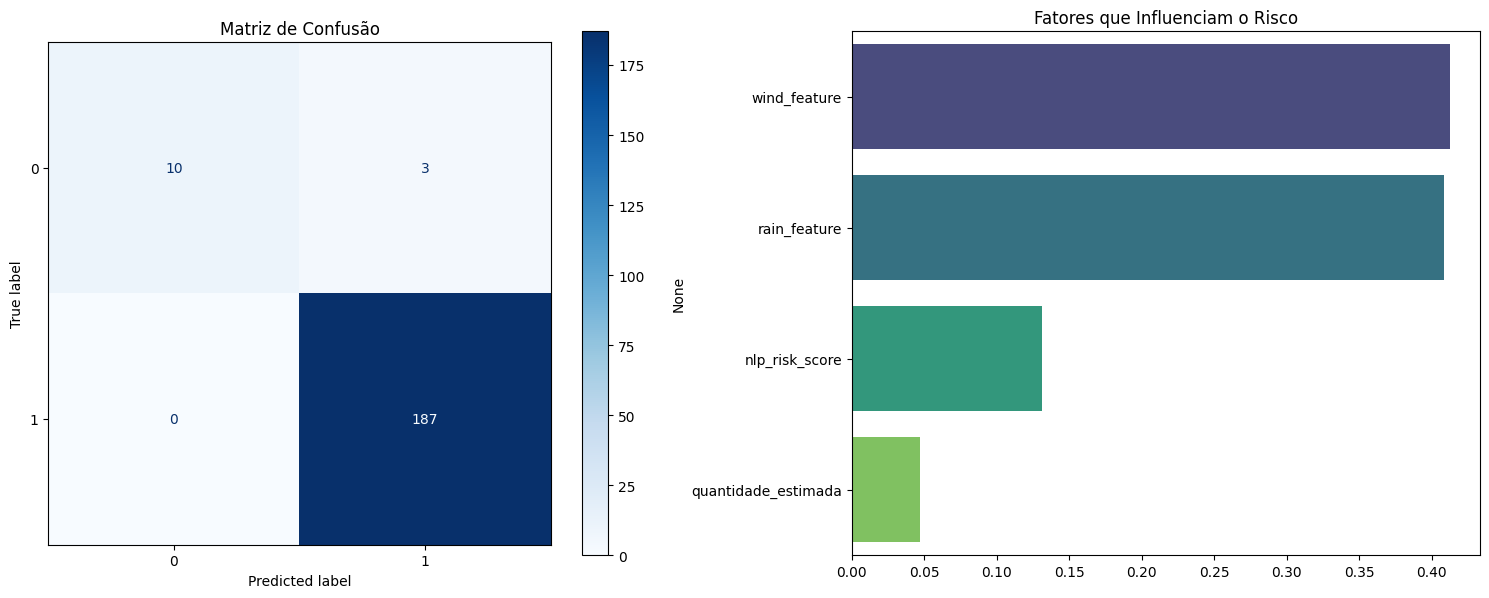


🔍 Insights do Modelo:
- wind_feature: 41.28%
- rain_feature: 40.87%
- nlp_risk_score: 13.10%
- quantidade_estimada: 4.75%


In [22]:
# 1. Seleção de Features
features = ['rain_feature', 'wind_feature', 'nlp_risk_score', 'quantidade_estimada']
X = df_ml[features]
y = df_ml['target_is_delayed']

# 2. Split de Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treinamento com Pesos Balanceados (O PULO DO GATO)
# Adicionamos class_weight='balanced' para compensar a falta de exemplos de atraso
# Use max_depth=None ou um valor alto para ele respeitar as regras do vento
model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    random_state=42
)
model.fit(X_train, y_train)

# 4. Avaliação de Performance
y_pred = model.predict(X_test)
print("\n📊 Relatório de Performance:")
print(classification_report(y_test, y_pred))

# --- VISUALIZAÇÃO SÊNIOR ---
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# A. Matriz de Confusão (Verificando Falsos Negativos)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusão")

# B. Importância das Features (Sem o aviso de palette do anterior)
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette='viridis', legend=False, ax=ax[1])
ax[1].set_title("Fatores que Influenciam o Risco")

plt.tight_layout()
plt.show()

print("\n🔍 Insights do Modelo:")
for feature, val in importancias.items():
    print(f"- {feature}: {val:.2%}")

In [23]:
# 1. Salvar o modelo treinado em um arquivo
model_filename = 'modelo_risco_demurrage_v1.pkl'
joblib.dump(model, model_filename)

print(f"✅ Modelo salvo com sucesso em: {model_filename}")

# 2. Exemplo de como carregar e usar no futuro (no Dashboard)
# modelo_carregado = joblib.load(model_filename)
# previsao = modelo_carregado.predict_proba(X_test) # Retorna a probabilidade (0.0 a 1.0)

✅ Modelo salvo com sucesso em: modelo_risco_demurrage_v1.pkl


F:\anaconda\envs\gemini_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


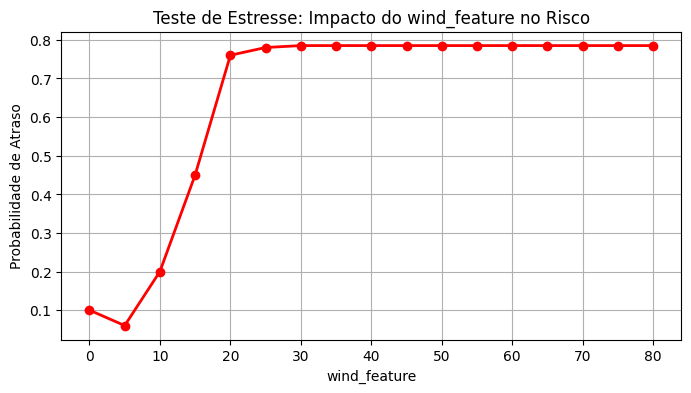

In [24]:
# --- VALIDAÇÃO DO CÉREBRO DO MODELO ---
import matplotlib.pyplot as plt

def stress_test_model(feature_name, range_values):
    test_cases = []
    for val in range_values:
        # Criamos um caso onde tudo é zero/médio, exceto a feature que estamos testando
        case = {
            'rain_feature': 0,
            'wind_feature': 0,
            'nlp_risk_score': 0,
            'quantidade_estimada': 50000
        }
        case[feature_name] = val
        test_cases.append(list(case.values()))
    
    probs = model.predict_proba(test_cases)[:, 1]
    
    plt.figure(figsize=(8, 4))
    plt.plot(range_values, probs, marker='o', color='red', linewidth=2)
    plt.title(f"Teste de Estresse: Impacto do {feature_name} no Risco")
    plt.xlabel(feature_name)
    plt.ylabel("Probabilidade de Atraso")
    plt.grid(True)
    plt.show()

# Testa o Vento de 0 a 80km/h
stress_test_model('wind_feature', range(0, 81, 5))

### Iniciando o EDA (Exploratory Data Analysis)

📊 Volume de Dados: Clima(416) | Navios(437)

🌡️ Resumo Estatístico do Clima:


,precipitacao_mm,velocidade_vento,umidade
count,416.000000,416.000000,416.000000
mean,14.111058,16.645673,84.780288
std,24.520421,3.754949,6.449903
min,0.000000,11.600000,75.500000
25%,0.700000,14.700000,80.000000
50%,5.900000,15.500000,83.100000
75%,16.800000,17.900000,88.425000
max,121.600000,29.400000,96.400000


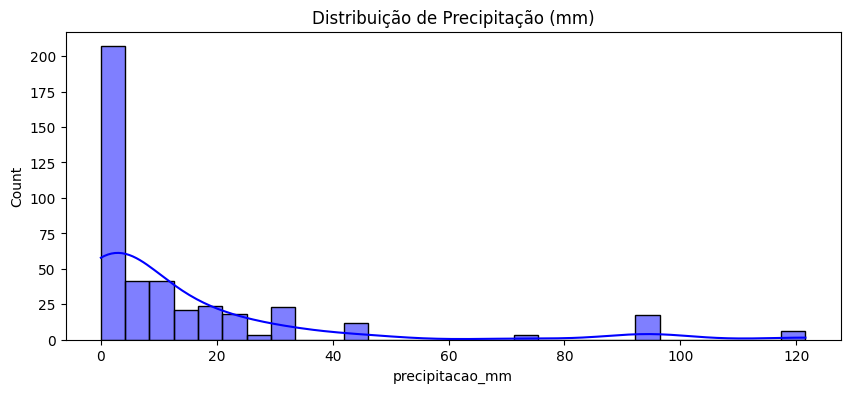


🚢 Top Terminais por Volume Esperado:
terminal
ALAMOA       252
ILHA          88
DOW           28
ALA.-I.B.     15
CUTRALE       14
Name: count, dtype: int64

📅 Distribuição de Chegadas (Próximos dias):
data_chegada_prevista
2026-02-21    13
2026-02-28    13
2026-03-03    14
2026-03-04    27
2026-03-05    26
2026-03-06    11
2026-03-09    14
2026-03-11    45
2026-03-12    15
2026-03-14     1
2026-03-15     6
2026-03-16     1
2026-03-17    14
2026-03-20     1
Name: count, dtype: int64


In [20]:
# 1. Trazer os dados crus para análise
df_clima_eda = client.query("SELECT * FROM `agrologisticsdata.logisticsdata.fato_clima`").to_dataframe()
df_navios_eda = client.query("SELECT * FROM `agrologisticsdata.logisticsdata.fato_lineup`").to_dataframe()

print(f"📊 Volume de Dados: Clima({len(df_clima_eda)}) | Navios({len(df_navios_eda)})")

# --- ANÁLISE DE VARIABILIDADE DO CLIMA ---
print("\n🌡️ Resumo Estatístico do Clima:")
display(df_clima_eda[['precipitacao_mm', 'velocidade_vento', 'umidade']].describe())

# Plotando a distribuição da chuva (Se tudo for 0, o modelo não tem o que aprender!)
plt.figure(figsize=(10, 4))
sns.histplot(df_clima_eda['precipitacao_mm'], kde=True, color='blue')
plt.title("Distribuição de Precipitação (mm)")
plt.show()

# --- ANÁLISE DE CONCENTRAÇÃO DE NAVIOS ---
print("\n🚢 Top Terminais por Volume Esperado:")
print(df_navios_eda['terminal'].value_counts().head(5))

# Verificando se as datas de chegada estão muito distantes ou todas no mesmo dia
print("\n📅 Distribuição de Chegadas (Próximos dias):")
print(df_navios_eda['data_chegada_prevista'].value_counts().sort_index())